# Step 4: Survey Existing Research and Reproduce Available Churn Prediction Solution

**Capstone Topic:** Customer churn prediction using machine learning  
**Dataset:** Bank Customer Churn / Churn Modelling dataset  
**Target Variable:** `Exited`  
**Objective:** Reproduce a common customer churn prediction workflow using a public churn dataset and compare baseline machine learning models.

This notebook supports Step 4 of the capstone by reproducing the type of workflow commonly found in public churn prediction implementations: load data, inspect the dataset, preprocess features, train baseline models, evaluate performance, and summarize what was learned.

## 1. Research Reference

For the research survey, I reviewed churn prediction research and a public implementation using Logistic Regression, Random Forest, and XGBoost.

Selected public implementation pattern:

- Data preprocessing
- Exploratory data analysis
- Categorical encoding
- Train/test split
- Baseline classification models
- Model evaluation using accuracy, precision, recall, F1-score, and ROC-AUC

This notebook reproduces the overall solution pattern using my selected capstone dataset.

## 2. Import Libraries

The libraries below are standard tools for tabular machine learning workflows in Python.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

## 3. Load Dataset

The dataset is loaded from a CSV file. If the file is stored in a different folder, update the file path below.

In [34]:
from pathlib import Path

possible_paths = [
    Path("../data/Customer Churn new.csv"),
    Path("data/Customer Churn new.csv"),
    Path("../Data/Customer Churn new.csv"),
    Path("Data/Customer Churn new.csv"),
]

DATA_PATH = next(
    (path for path in possible_paths if path.exists()),
    None
)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find Data/Customer Churn new.csv."
    )

print(f"Loading dataset from: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
df.head()

Loading dataset from: /Users/jeffreyjolly/Desktop/ML:AI Capstone/data/Customer Churn new.csv


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary,Exited
0,747,15787619,Hsieh,844,France,Male,18,2,160980.03,145936.28,0
1,1620,15770309,McDonald,656,France,Male,18,10,151762.74,127014.32,0
2,1679,15569178,Kharlamov,570,France,Female,18,4,82767.42,71811.90,0
3,2022,15795519,Vasiliev,716,Germany,Female,18,3,128743.80,197322.13,0
4,2137,15621893,Bellucci,727,France,Male,18,4,133550.67,46941.41,0


## 4. Initial Data Inspection

This section checks the shape of the dataset, column names, data types, missing values, and summary statistics.

In [35]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (10000, 11)

Columns:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'Exited']


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 859.5+ KB


In [37]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,199992.480000,1.000000


In [38]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
EstimatedSalary    0
Exited             0
dtype: int64

In [39]:
df.duplicated().sum()

0

## 5. Target Variable Review

The target variable is `Exited`, where:

- `0` means the customer stayed
- `1` means the customer exited / churned

This step checks the class balance.

In [40]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [41]:
df["Exited"].value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

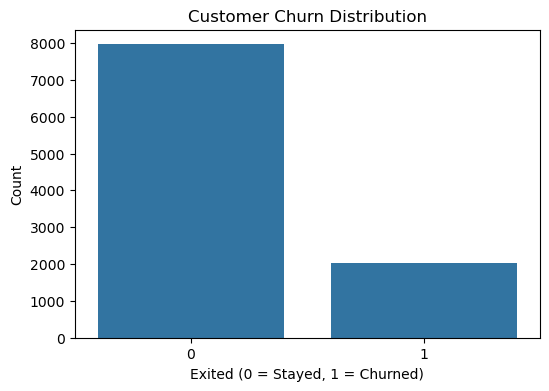

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(x="Exited", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Count")
plt.show()

## 6. Data Cleaning Decisions

The following columns are removed before modeling:

- `RowNumber`: row identifier with no predictive business meaning
- `CustomerId`: unique customer identifier
- `Surname`: customer name, which should not be used to predict churn

These fields are identifiers rather than meaningful customer behavior or account attributes.

In [43]:
df_clean = df.copy()

columns_to_drop = ["RowNumber", "CustomerId", "Surname"]
df_clean = df_clean.drop(columns=columns_to_drop)

df_clean.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary,Exited
0,844,France,Male,18,2,160980.03,145936.28,0
1,656,France,Male,18,10,151762.74,127014.32,0
2,570,France,Female,18,4,82767.42,71811.90,0
3,716,Germany,Female,18,3,128743.80,197322.13,0
4,727,France,Male,18,4,133550.67,46941.41,0


## 7. Exploratory Data Analysis

This section explores the relationship between selected features and customer churn.

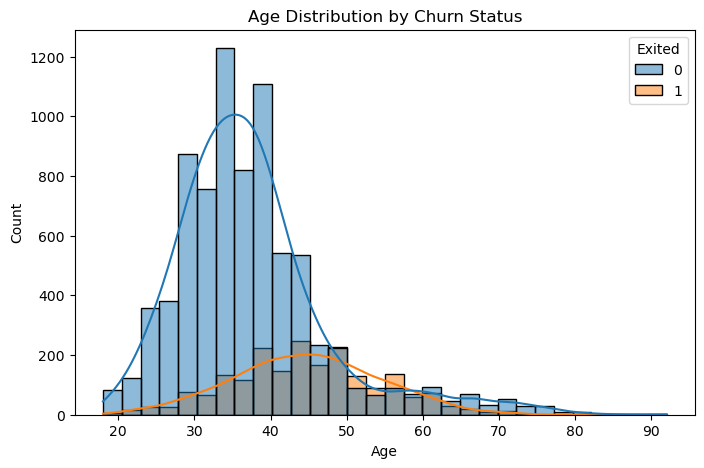

In [44]:
plt.figure(figsize=(8,5))
sns.histplot(data=df_clean, x="Age", hue="Exited", bins=30, kde=True)
plt.title("Age Distribution by Churn Status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

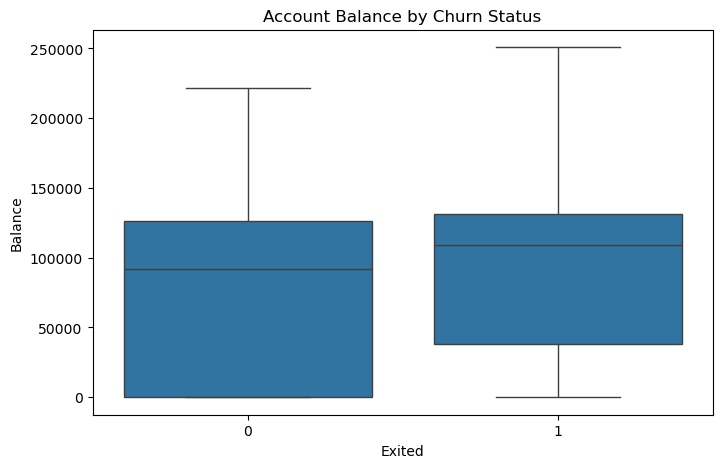

In [45]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x="Exited", y="Balance")
plt.title("Account Balance by Churn Status")
plt.xlabel("Exited")
plt.ylabel("Balance")
plt.show()

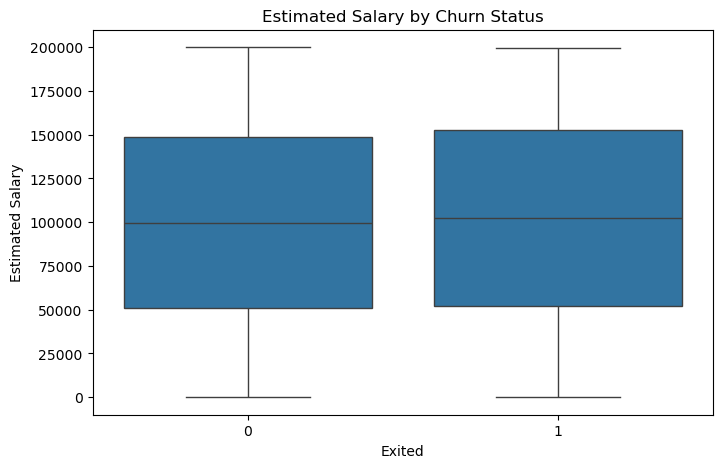

In [46]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x="Exited", y="EstimatedSalary")
plt.title("Estimated Salary by Churn Status")
plt.xlabel("Exited")
plt.ylabel("Estimated Salary")
plt.show()

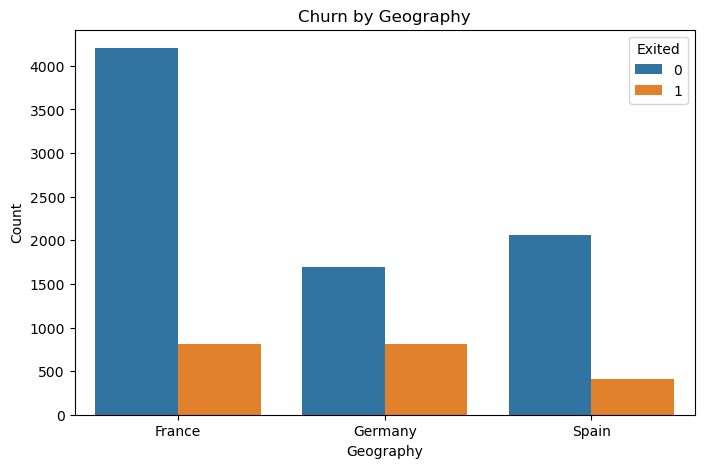

In [47]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x="Geography", hue="Exited")
plt.title("Churn by Geography")
plt.xlabel("Geography")
plt.ylabel("Count")
plt.show()

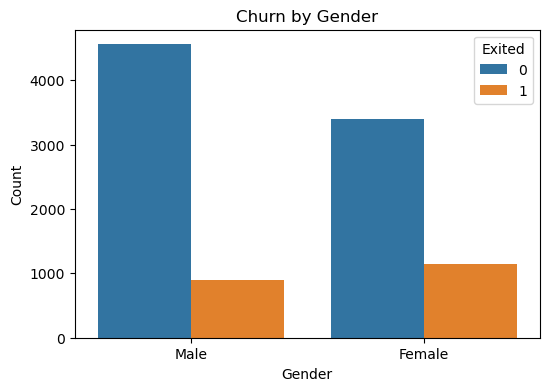

In [48]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x="Gender", hue="Exited")
plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

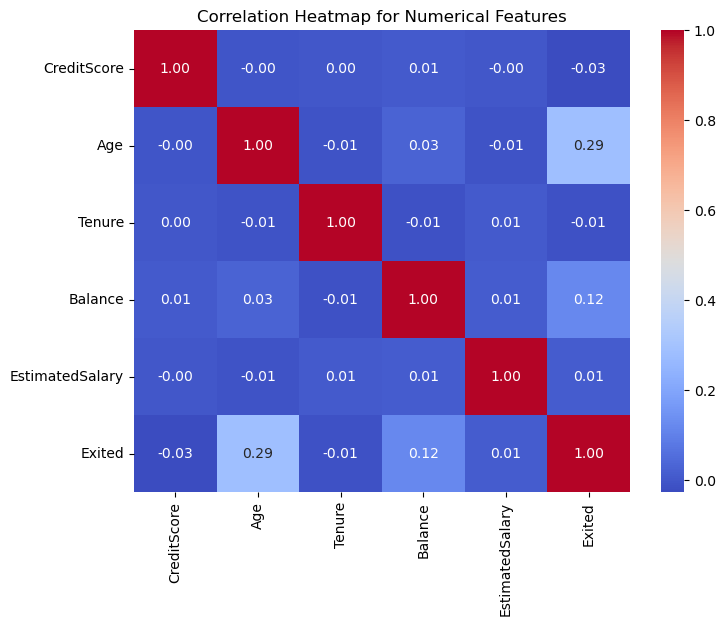

In [49]:
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(8,6))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap for Numerical Features")
plt.show()

## 8. Feature Preparation

The dataset contains both numerical and categorical predictors.

Categorical features:
- `Geography`
- `Gender`

Numerical features:
- `CreditScore`
- `Age`
- `Tenure`
- `Balance`
- `EstimatedSalary`

The modeling pipeline will one-hot encode categorical features and scale numerical features.

In [50]:
X = df_clean.drop("Exited", axis=1)
y = df_clean["Exited"]

categorical_features = ["Geography", "Gender"]
numeric_features = [col for col in X.columns if col not in categorical_features]

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

Categorical features: ['Geography', 'Gender']
Numeric features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']


## 9. Train/Test Split

The dataset is split into training and testing sets. Stratification is used so that the churn distribution is similar in both sets.

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (8000, 7)
Testing set size: (2000, 7)


## 10. Preprocessing Pipeline

This preprocessing pipeline handles numeric scaling and categorical one-hot encoding consistently for both models.

In [52]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## 11. Helper Function for Model Evaluation

This function evaluates model performance using common binary classification metrics.

In [53]:
def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    }

    print(f"\n{model_name} Classification Report")
    print(classification_report(y_test, y_pred))

    print(f"\n{model_name} Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    return results

## 12. Baseline Model: Logistic Regression

Logistic Regression is used as the baseline model because it is simple, fast, and interpretable.

In [54]:
log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

log_reg_model.fit(X_train, y_train)

log_reg_results = evaluate_model("Logistic Regression", log_reg_model, X_test, y_test)
log_reg_results


Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.81      0.96      0.88      1593
           1       0.45      0.12      0.19       407

    accuracy                           0.79      2000
   macro avg       0.63      0.54      0.54      2000
weighted avg       0.74      0.79      0.74      2000


Logistic Regression Confusion Matrix
[[1532   61]
 [ 357   50]]


{'Model': 'Logistic Regression',
 'Accuracy': 0.791,
 'Precision': 0.45045045045045046,
 'Recall': 0.12285012285012285,
 'F1 Score': 0.19305019305019305,
 'ROC AUC': 0.7529563461766852}

## 13. Comparison Model: Random Forest

Random Forest is used as a comparison model because it can capture nonlinear relationships and feature interactions.

In [55]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

rf_results = evaluate_model("Random Forest", rf_model, X_test, y_test)
rf_results


Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      1593
           1       0.60      0.29      0.40       407

    accuracy                           0.82      2000
   macro avg       0.72      0.62      0.64      2000
weighted avg       0.79      0.82      0.79      2000


Random Forest Confusion Matrix
[[1514   79]
 [ 287  120]]


{'Model': 'Random Forest',
 'Accuracy': 0.817,
 'Precision': 0.6030150753768844,
 'Recall': 0.29484029484029484,
 'F1 Score': 0.39603960396039606,
 'ROC AUC': 0.7664174189597919}

## 14. Model Comparison

The results from Logistic Regression and Random Forest are compared below.

In [56]:
results_df = pd.DataFrame([log_reg_results, rf_results])
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.791,0.450450,0.12285,0.19305,0.752956
1,Random Forest,0.817,0.603015,0.29484,0.39604,0.766417


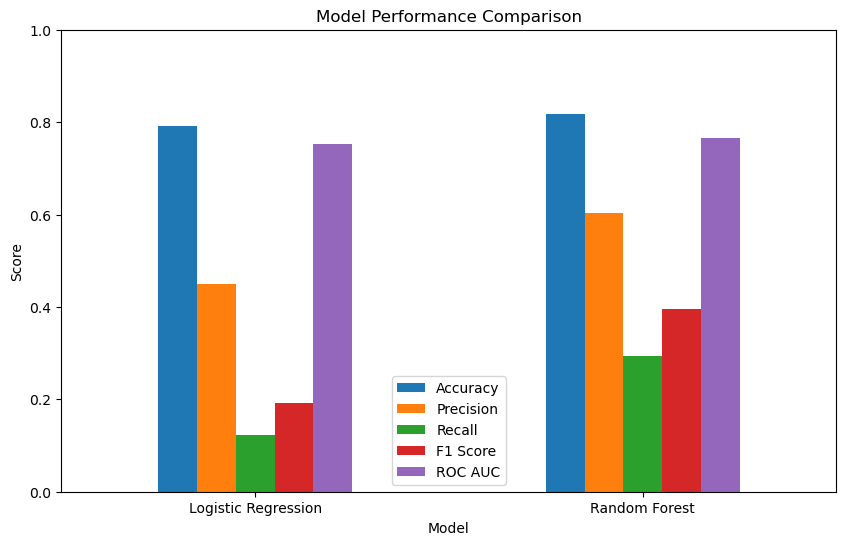

In [57]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]].plot(
    kind="bar",
    figsize=(10,6)
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## 15. Feature Importance from Random Forest

Feature importance helps explain which variables contributed most to the Random Forest model.

In [58]:
# Get feature names after preprocessing
encoded_cat_features = rf_model.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_features, encoded_cat_features])

feature_importances = rf_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
1,Age,0.297380
4,EstimatedSalary,0.195721
0,CreditScore,0.186389
3,Balance,0.158865
2,Tenure,0.098927
6,Geography_Germany,0.023029
8,Gender_Female,0.010783
5,Geography_France,0.010363
9,Gender_Male,0.009441
7,Geography_Spain,0.009102


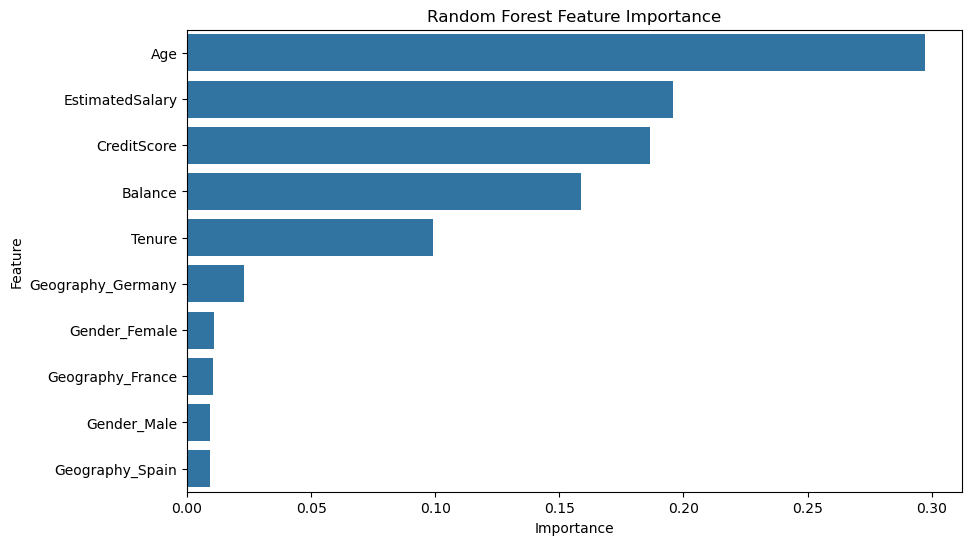

In [59]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 16. Reproduction Summary

This notebook reproduced a common churn prediction workflow found in public machine learning implementations:

1. Loaded a customer churn dataset.
2. Inspected the dataset structure.
3. Checked missing values and duplicates.
4. Removed non-predictive identifier columns.
5. Explored churn patterns through visualizations.
6. Encoded categorical variables and scaled numerical features.
7. Trained a Logistic Regression baseline model.
8. Trained a Random Forest comparison model.
9. Evaluated models using accuracy, precision, recall, F1-score, and ROC-AUC.
10. Reviewed feature importance for basic interpretability.

## 17. What I Learned

The reproduction showed that churn prediction can be approached effectively using traditional machine learning methods on structured tabular data. Logistic Regression provides a useful baseline because it is simple and interpretable, while Random Forest can capture more complex relationships in the data.

The results also show that model evaluation should include more than accuracy. In churn prediction, recall and F1-score are important because missing customers who are likely to churn may be costly for the business. ROC-AUC provides another useful measure of how well the model separates customers who stay from customers who exit.

This notebook establishes a baseline workflow for the capstone project. Future work will expand on this by improving feature engineering, testing additional models, refining evaluation, and packaging the final model into a lightweight application or API.